In [10]:
# _rd_00.py 
# SDL, SRL, simple case 
# 상관관계, 상관계수, 공분산, 산포도. 그룹, 히스토그램 등 회귀분석 전 설명.

# 이 코드 - 산포도와 중심점 표시. SDL 표시 
# compute subgroup mean of y by x-classes, 이거 계산 간단히 하자...
# raw data - x: 키, y: 체중, n = 3111 
# mean function in regression. 작업예정... 

import os
import numpy as np                          # numpy 라이브러리 전체. 
import pandas as pd                         # pandas 라이브러리 전체, 시계열(기본) 여기 있네. 
import scipy as sci 
from scipy import stats, optimize, linalg   # scipy 라이브러리 하부 모듈. 필요한 통계 모듈만.
import statsmodels.api as sm                # 방대한 모델이라 개발자들이 많이 쓰는 모델 묶음.
from statsmodels.tsa import stattools       # time series analysis 
from statsmodels.tsa.arima.model import ARIMA # 이거 가능하다 이거지. 이거 대문자네. 꼭. 소문자 못읽어.
import matplotlib.pyplot as plt


In [11]:

# 데이터 파일 읽기. github.com
dat_url = 'https://github.com/bahn28/gamja/blob/main/cs_nns_hgt_wgt.xlsx?raw=true'
df_dat = pd.read_excel(dat_url) 
df_dat.head() 


,x,y
0,174.262367,70.149796
1,166.350641,60.169389
2,158.381596,63.394676
3,163.472285,46.948571
4,157.954485,49.428887


In [12]:
# 1. 데이터 준비. 읽기. 생성. 
n_obs = len(df_dat) 
hgt = df_dat['x'].to_numpy()
wgt = df_dat['y'].to_numpy()
#    gndr = (gndrlit == 'Male').astype(int)   # astype(int)으로 NumPy 배열 전환, 1/0  


# 2. 자료 검토, 요약, 그래프 생성.
# 2a. 자료 검토, 기초 통계량
summ = df_dat.agg(
            ["count", "mean", "std", "min", "median", "max"]
            ) # 일부 변수, 일부 통계량 
# print(summ)
summ.head(7)


,x,y
count,3111.000000,3111.000000
mean,167.076163,63.463587
std,8.599366,12.642302
min,138.146769,20.077826
median,167.040445,63.680696
max,198.211156,106.538459


In [13]:
# 평균점, 분산, 상관계수 
mean_x = hgt.mean()
mean_y = wgt.mean() 
sig_x = hgt.std(ddof=1)
sig_y = wgt.std(ddof=1)
r_xy = np.corrcoef(hgt, wgt)[0,1]  # 상관계수 행렬의 한 원소.
c_xy = np.cov(hgt, wgt)[0, 1]      # 공분산

# SDL, SRL, 준비
b_sdl = (sig_y/sig_x) 
a_sdl = mean_y - b_sdl * mean_x 

b_srl = r_xy*(sig_y/sig_x) 
a_srl = mean_y - b_srl * mean_x 

x_span = np.linspace(130, 200)
y_sdl = a_sdl + b_sdl * x_span 
y_srl = a_srl + b_srl * x_span 

# 키 그룹별 자료 준비.
dat_1 = df_dat[(df_dat['x'] > 155.99) & (df_dat['x'] < 158)] # 밴드 1. 작은 키 소그룹
x_g1 = dat_1['x'] 
y_g1 = dat_1['y'] 
x_g1_mean = x_g1.mean()   # 밴드의 중심
y_g1_mean = y_g1.mean()

dat_2 = df_dat[(df_dat['x'] > 165.99) & (df_dat['x'] < 168)] # 밴드 2. 평균 키 소그룹
x_g2 = dat_2['x'] 
y_g2 = dat_2['y'] 
x_g2_mean = x_g2.mean()   # 밴드의 중심
y_g2_mean = y_g2.mean()

dat_3 = df_dat[(df_dat['x'] > 175.99) & (df_dat['x'] < 178)] # 밴드 3. 큰 키 소그룹
x_g3 = dat_3['x'] 
y_g3 = dat_3['y'] 
x_g3_mean = x_g3.mean()   # 밴드의 중심
y_g3_mean = y_g3.mean()


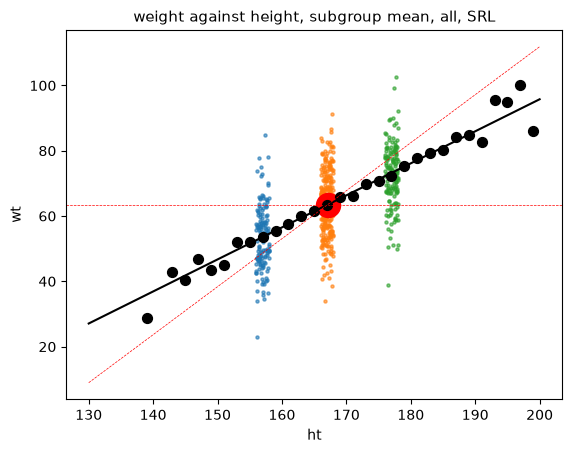

In [35]:
# x 소그룹별 구간, y 평균.
bin_stp = 2
bin_beg = int( hgt.min() ) - bin_stp 
bin_end = int( hgt.max() ) + bin_stp 
mean_gs = []
bin_gs = []
bin_cnt =[]
for left in range(bin_beg, bin_end, bin_stp):      # 130, 134, ..., 198
    mask = ( hgt >= left) & (hgt < left + bin_stp )
    bin_cnt.append(left + bin_stp /2 )   
    bin_gs.append((left, left + bin_stp))
    if np.any(mask):
        mean_gs.append(np.mean(wgt[mask]))
    else:
        mean_gs.append(np.nan)


# 2c. 자료 검토, 시각화 확인.
# 산포도 ( x, y )  
fig = plt.figsize=(10, 10)         # 이건 tuple 
# fig = plt.figure(figsize=(10, 8))  # 이건 객체. 
#    plt.scatter(hgt, wgt, s=5, alpha=0.6 ) #facecolor='none', edgecolor='black')
plt.scatter(x_g1, y_g1, s=5, alpha=0.6 ) #facecolor='none', edgecolor='black')
plt.scatter(x_g2, y_g2, s=5, alpha=0.6 ) #facecolor='none', edgecolor='black')
plt.scatter(x_g3, y_g3, s=5, alpha=0.6 ) #facecolor='none', edgecolor='black')
plt.scatter(mean_x, mean_y, s=300, c='red', marker='o')
#    plt.axvline(mean_x, color='red', linestyle='--', lw=0.8)
plt.axhline(mean_y, color='red', linestyle='--', lw=0.5)
plt.scatter(bin_cnt, mean_gs, s=50, c='black', marker='o')
    # plt.scatter(mean_xg1, mean_yg1, s=100, c='black', marker='o')
    # plt.scatter(mean_xg2, mean_yg2, s=100, c='black', marker='o')
    # plt.scatter(mean_xg3, mean_yg3, s=100, c='black', marker='o')
#    plt.scatter(x, y, s=10, c='green', marker='o')
plt.plot(x_span, y_srl, color='black', linewidth=1.5)
plt.plot(x_span, y_sdl, color='red', linewidth= 0.5 , linestyle='--')
plt.title(" weight against height, subgroup mean, all, SRL ", fontsize=11)
plt.xlabel(" ht ")
plt.ylabel(" wt ")
plt.show()
